##OpenCV manipulation basics
#01 Getting started

In [2]:
import cv2 as cv
import sys
import matplotlib.pyplot as plt

#01. Basic image manipulation

In [3]:
img = cv.imread("test.png")

if img is None:
    sys.exit('could not load image...')

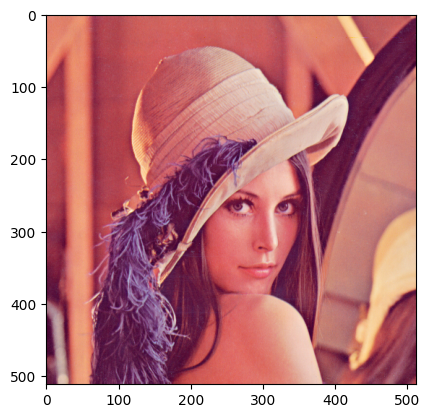

In [4]:
#convert img to RGB before displaying it - OpenCV reads BGR and plt RGB
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()

In [5]:
img_rgb.shape
img_rgb.dtype

dtype('uint8')

In [6]:
img_rgb.min()
img_rgb.max()

np.uint8(255)

In [7]:
img_comp = cv.resize(img_rgb, (1024,1024))
img_comp.shape

(1024, 1024, 3)

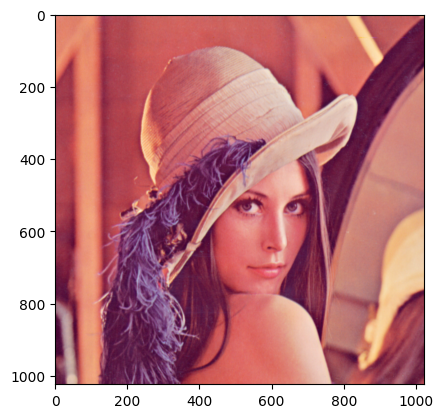

In [8]:
plt.imshow(img_comp)
plt.show()

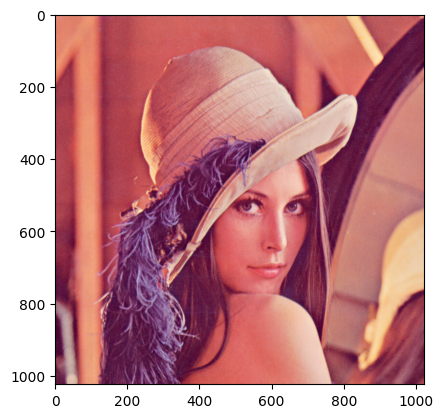

In [9]:
img_comp_2 = cv.resize(img_rgb, (1024,1024), interpolation=cv.INTER_LANCZOS4)
plt.imshow(img_comp_2)
plt.show()

#02 Normalization

In [10]:
img_norm = img_rgb/255.0
img_rgb.std()
img_norm.std()


np.float64(0.23130872389600074)

#03 Blurring

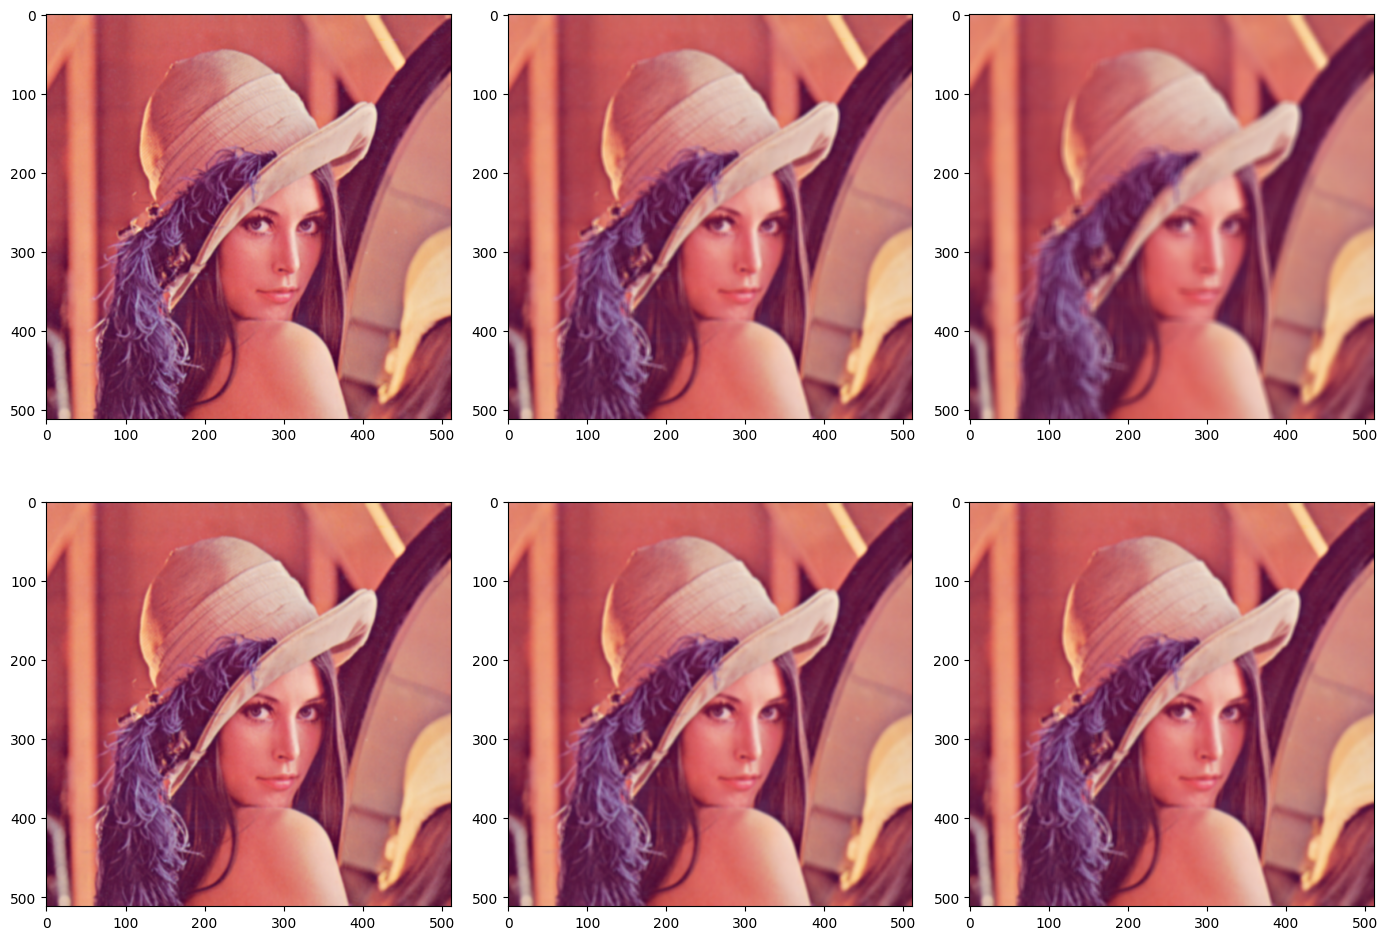

In [15]:
fig,axes = plt.subplots(nrows=2, ncols=3, figsize=(14,10))
img_blur_1 = cv.blur(img_rgb, (3,3))
img_blur_2 = cv.blur(img_rgb, (5,5))
img_blur_3 = cv.blur(img_rgb, (9,9))

img_gauss_blur_1 = cv.GaussianBlur(img_rgb, (5,5), cv.BORDER_CONSTANT)
img_gauss_blur_2 = cv.GaussianBlur(img_rgb, (5,5), cv.BORDER_REFLECT)
img_gauss_blur_3 = cv.GaussianBlur(img_rgb, (5,5), cv.BORDER_WRAP)

axes[0,0].imshow(img_blur_1)
axes[0,1].imshow(img_blur_2)
axes[0,2].imshow(img_blur_3)


axes[1,0].imshow(img_gauss_blur_1)
axes[1,1].imshow(img_gauss_blur_2)
axes[1,2].imshow(img_gauss_blur_3)

plt.tight_layout()
plt.show()

#04. Edge detection using canny

[]

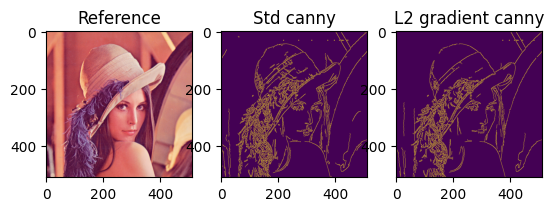

In [12]:
'''additional research : how to set correctly hysteresis?'''
fig2, axes2 = plt.subplots(nrows=1, ncols=3)
edges = cv.Canny(img_rgb,100,200)
edges_L2 = cv.Canny(img_rgb,100,200, L2gradient=True)

axes2[0].imshow(img_rgb)
axes2[0].set_title('Reference')
axes2[1].imshow(edges)
axes2[1].set_title('Std canny')
axes2[2].imshow(edges_L2)
axes2[2].set_title('L2 gradient canny')

plt.plot()

#05. Thresholding

[]

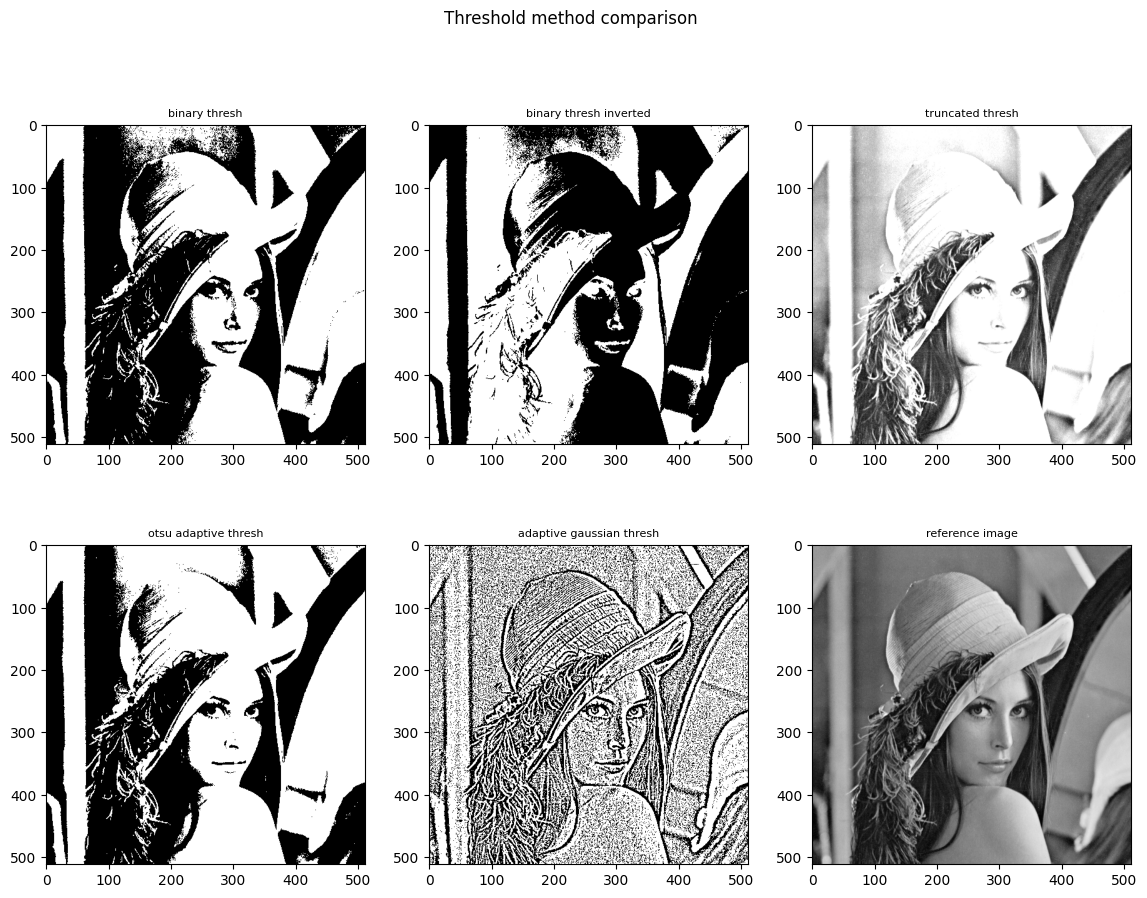

In [13]:
#05. Seuillage
'''first let's convert our image into a greyscale image'''
img_grey = cv.cvtColor(img_rgb, cv.COLOR_RGB2GRAY)

fig3, axes3 = plt.subplots(nrows=2, ncols=3, figsize=(14,10))

axes3[1,2].imshow(img_grey, cmap='grey')
axes3[1,2].set_title('reference image', fontsize=8)

'''First example : binary thresholding'''
retval, img_thr_bin = cv.threshold(img_grey, 127, 255, cv.THRESH_BINARY)
axes3[0,0].imshow(img_thr_bin, cmap='grey')
axes3[0,0].set_title('binary thresh', fontsize=8)
'''Second example: inverted'''
retval, img_thr_bin_inv = cv.threshold(img_grey, 127, 255, cv.THRESH_BINARY_INV)
axes3[0,1].imshow(img_thr_bin_inv, cmap='grey')
axes3[0,1].set_title('binary thresh inverted', fontsize=8)
'''third example: truncate'''
retval, img_thr_trunc = cv.threshold(img_grey, 127, 255, cv.THRESH_TRUNC)
axes3[0,2].imshow(img_thr_trunc, cmap='grey')
axes3[0,2].set_title('truncated thresh', fontsize=8)
'''Fourth example : otsu binarization'''
retval, img_thr_bin_otsu = cv.threshold(img_grey, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
axes3[1,0].imshow(img_thr_bin_otsu, cmap='grey')
axes3[1,0].set_title('otsu adaptive thresh', fontsize=8)
'''Fifth example : adaptive thresholding'''
img_thr_adapt = cv.adaptiveThreshold(img_grey, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 2)
axes3[1,1].imshow(img_thr_adapt, cmap='grey')
axes3[1,1].set_title('adaptive gaussian thresh', fontsize=8)

fig3.suptitle('Threshold method comparison')

plt.plot()



###comments
Due to its local nature, adaptive gaussian thresholding is excellent at highlighting details in an image, but is sensitive to noise. Otsu seems more robust, especially for image with high contrast, which can be an interesting feature for this project (indeed, production line inspection often features a uniform background, with the item to be analysed clearly separated from the background). Binary thresholding also is a strong candidate : if these images are taken with the same device, in the same conditions (lighting, focal distance...), these controlled conditions make it worth considering. It could bring good computational gains due to its simple nature. We'll consider that when exploring the MVTec dataset!

#06. Histograms

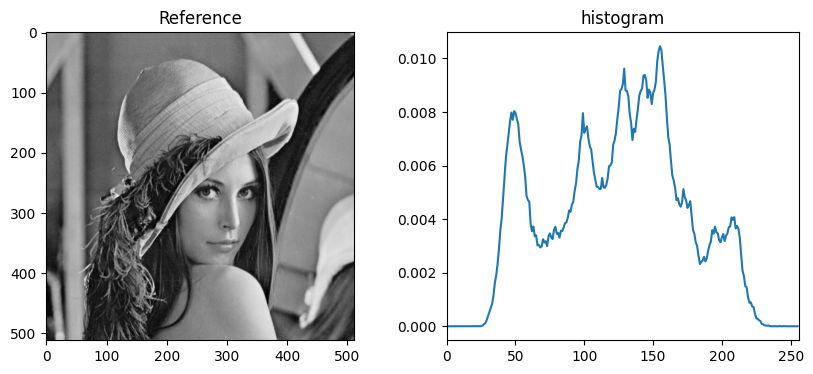

In [14]:
#first example with greyscale image
hist = cv.calcHist([img_grey], [0], None, [256], [0,256])
hist /= hist.sum()
fig_gs_hist, ax_gs_hist = plt.subplots(1,2, figsize=(10,4))

ax_gs_hist[0].imshow(img_grey, cmap='grey')
ax_gs_hist[0].set_title('Reference')

ax_gs_hist[1].plot(hist)
ax_gs_hist[1].set_title('histogram')
ax_gs_hist[1].set_xlim([0,256])

plt.show()

#07. Morphology

#08. Crop & patch

#9. Miscellaneous